In [3]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))


In [6]:
import importlib
import src.eda
importlib.reload(src.eda)

from src.data_loader import load_unified_data, split_by_record_type
from src.eda import plot_indicator_trend, plot_indicator_with_events
from src.forecasting import trend_forecast, scenario_forecast

df = load_unified_data(r"C:\Users\hp\Pictures\Forecasting Financial Inclusion in Ethiopia\Forecasting-Financial-Inclusion-in-Ethiopia\data\raw\ethiopia_fi_unified_data.csv")
obs, events, targets, impact_links = split_by_record_type(df)

# Access (Findex)
plot_indicator_trend(
    obs,
    indicator_code="ACC_OWNERSHIP",
    title="Account Ownership – Ethiopia",
    ylabel="% of adults"
)


# Usage (operator / survey based)
plot_indicator_trend(
    obs,
    indicator_code="USG_MM_ACCOUNT",
    title="Mobile Money Account Penetration – Ethiopia",
    ylabel="% of adults"
)



# Forecast
access_series = (
    obs[obs["indicator_code"] == "ACC_OWNERSHIP"]
    .set_index("year")["value_numeric"]
)

forecast = trend_forecast(access_series, 2025, 2027)
forecast_opt = scenario_forecast(forecast, "optimistic")
forecast_pess = scenario_forecast(forecast, "pessimistic")


ImportError: cannot import name 'plot_indicator_with_events' from 'src.eda' (c:\Users\hp\Pictures\Forecasting Financial Inclusion in Ethiopia\Forecasting-Financial-Inclusion-in-Ethiopia\src\eda.py)

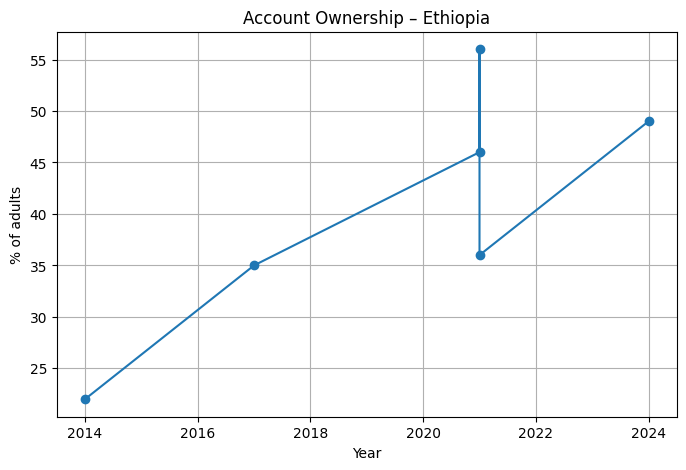

ValueError: No observation data found for USG_MM_ACCOUNT

In [7]:
import importlib
import src.eda
importlib.reload(src.eda)

from src.data_loader import load_unified_data, split_by_record_type
from src.eda import plot_indicator_trend  # just import the working function
from src.forecasting import trend_forecast, scenario_forecast

df = load_unified_data(r"C:\Users\hp\Pictures\Forecasting Financial Inclusion in Ethiopia\Forecasting-Financial-Inclusion-in-Ethiopia\data\raw\ethiopia_fi_unified_data.csv")
obs, events, targets, impact_links = split_by_record_type(df)

# Access (Findex)
plot_indicator_trend(
    obs,
    indicator_code="ACC_OWNERSHIP",
    title="Account Ownership – Ethiopia",
    ylabel="% of adults"
)

# Usage (operator / survey based)
plot_indicator_trend(
    obs,
    indicator_code="USG_MM_ACCOUNT",
    title="Mobile Money Account Penetration – Ethiopia",
    ylabel="% of adults"
)

# Forecast
access_series = (
    obs[obs["indicator_code"] == "ACC_OWNERSHIP"]
    .set_index("year")["value_numeric"]
)

forecast = trend_forecast(access_series, 2025, 2027)
forecast_opt = scenario_forecast(forecast, "optimistic")
forecast_pess = scenario_forecast(forecast, "pessimistic")

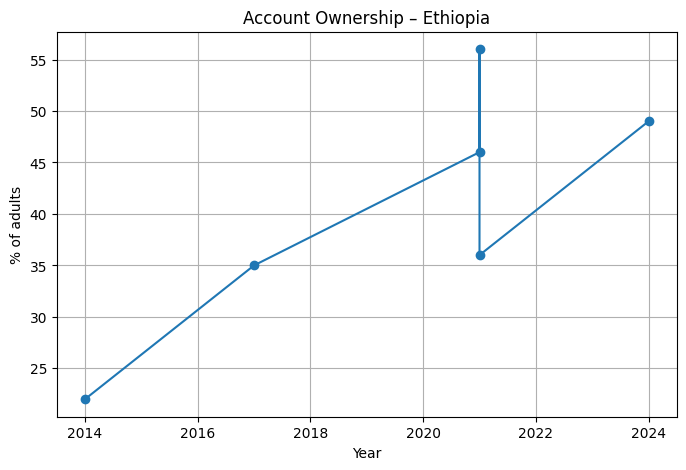

No observation data found for 'USG_MM_ACCOUNT'.


In [9]:
# Access (Findex)
plot_indicator_trend(
    obs,
    indicator_code="ACC_OWNERSHIP",
    title="Account Ownership – Ethiopia",
    ylabel="% of adults"
)

# Usage (operator / survey based)
if obs[(obs["record_type"] == "observation") & (obs["indicator_code"] == "USG_MM_ACCOUNT")].empty:
    print("No observation data found for 'USG_MM_ACCOUNT'.")
else:
    plot_indicator_trend(
        obs,
        indicator_code="ACC_MM_ACCOUNT",
        title="Mobile Money Account Penetration – Ethiopia",
        ylabel="% of adults"
    )

# Forecast
access_series = (
    obs[obs["indicator_code"] == "ACC_OWNERSHIP"]
    .set_index("year")["value_numeric"]
)

forecast = trend_forecast(access_series, 2025, 2027)
forecast_opt = scenario_forecast(forecast, "optimistic")
forecast_pess = scenario_forecast(forecast, "pessimistic")

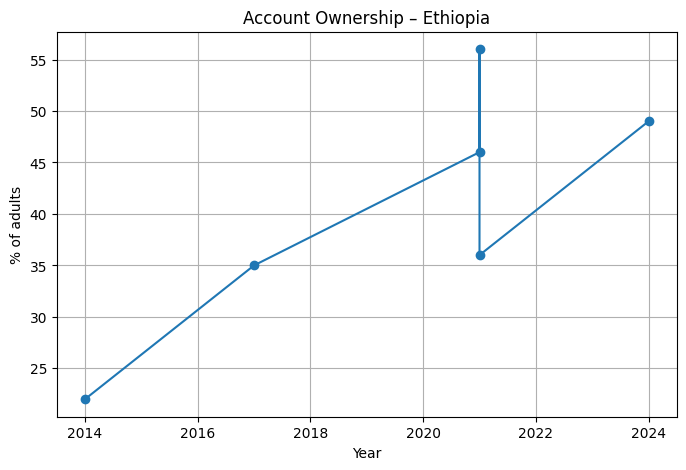

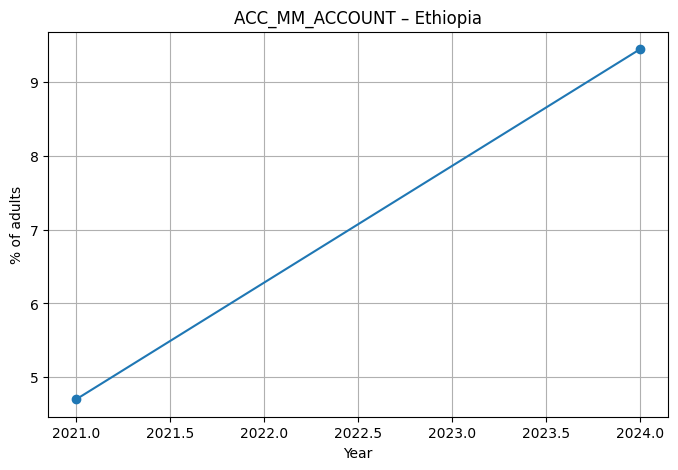

In [11]:
# Access (Findex)
plot_indicator_trend(
    obs,
    indicator_code="ACC_OWNERSHIP",
    title="Account Ownership – Ethiopia",
    ylabel="% of adults"
)

# Usage (operator / survey based)
alternative_indicator = "ACC_MM_ACCOUNT"  # You can change this to an appropriate indicator
if obs[(obs["record_type"] == "observation") & (obs["indicator_code"] == alternative_indicator)].empty:
    print(f"No observation data found for '{alternative_indicator}'. Using 'USG_MPESA_USERS'.")
    alternative_indicator = "USG_MPESA_USERS"  # Fallback to another existing one

plot_indicator_trend(
    obs,
    indicator_code=alternative_indicator,
    title=f"{alternative_indicator} – Ethiopia",
    ylabel="% of adults"
)

# Forecast
access_series = (
    obs[obs["indicator_code"] == "ACC_OWNERSHIP"]
    .set_index("year")["value_numeric"]
)

forecast = trend_forecast(access_series, 2025, 2027)
forecast_opt = scenario_forecast(forecast, "optimistic")
forecast_pess = scenario_forecast(forecast, "pessimistic")

In [10]:
print(obs['indicator_code'].unique())

['ACC_OWNERSHIP' 'ACC_MM_ACCOUNT' 'ACC_4G_COV' 'ACC_MOBILE_PEN'
 'ACC_FAYDA' 'USG_P2P_COUNT' 'USG_P2P_VALUE' 'USG_ATM_COUNT'
 'USG_ATM_VALUE' 'USG_CROSSOVER' 'USG_TELEBIRR_USERS' 'USG_TELEBIRR_VALUE'
 'USG_MPESA_USERS' 'USG_MPESA_ACTIVE' 'USG_ACTIVE_RATE' 'AFF_DATA_INCOME'
 'GEN_GAP_ACC' 'GEN_MM_SHARE' 'GEN_GAP_MOBILE' 'new_indicator']


In [21]:
obs["indicator_code"].value_counts()


indicator_code
ACC_OWNERSHIP         6
ACC_FAYDA             3
ACC_4G_COV            2
ACC_MM_ACCOUNT        2
GEN_GAP_ACC           2
USG_P2P_COUNT         2
ACC_MOBILE_PEN        1
USG_P2P_VALUE         1
USG_ATM_VALUE         1
USG_CROSSOVER         1
USG_TELEBIRR_USERS    1
USG_ATM_COUNT         1
USG_TELEBIRR_VALUE    1
USG_MPESA_USERS       1
USG_ACTIVE_RATE       1
USG_MPESA_ACTIVE      1
AFF_DATA_INCOME       1
GEN_MM_SHARE          1
GEN_GAP_MOBILE        1
new_indicator         1
Name: count, dtype: int64

In [1]:
def plot_indicator_trend(df, indicator_code, title, ylabel):
    data = (
        df[df["indicator_code"] == indicator_code]
        .dropna(subset=["year", "value_numeric"])
        .sort_values("year")
    )

    if data.empty:
        available = (
            df["indicator_code"]
            .dropna()
            .unique()
        )
        raise ValueError(
            f"No data found for {indicator_code}. "
            f"Available indicators: {sorted(available)}"
        )

    plt.figure(figsize=(8, 5))
    plt.plot(data["year"], data["value_numeric"], marker="o")
    plt.title(title)
    plt.ylabel(ylabel)
    plt.xlabel("Year")
    plt.show()
